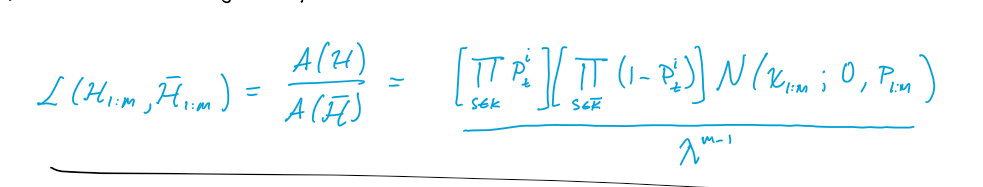

In [33]:
import numpy as np
from scipy.stats import multivariate_normal

In [3]:
true_states = np.random.uniform(-5, 5, 1000)

In [62]:
N = (2,)#(2, 3, 4)
rho = (0.1,) # (0, .1, .3, .5)



for r in rho:
    for n in N:

        # ------------ 1. For each object, generate one track per sensors -----------
        # We do this by generating the correlated errors and adding them to the true state
        # of the objects of interest, as shown by equation 45/46 in the appendix. 
        # ----------------------------------------------------------------------------
        
        # error shape (n_states, n_objects, n_sensors)
        err_cov = np.full((n, n), r)
        np.fill_diagonal(err_cov, 1.0)
        err = np.random.multivariate_normal(np.zeros(n), err_cov, size=1000).T

        # err + true_states --> (n_sensors, n_objects) + (n_objects) = (n_sensors, n_objects)
        tracks = err + true_states[None, :]

        # --------------------------------------------------------------------------
        # ----------- 2. Form candidate track associations -------------------------
        # NOTE: the track tensor can be used for valid associations. For example track[:, j] 
        #       gives all measurements associated with object j. So, we only need to form the 
        #       invalid associations. 
        # --------------------------------------------------------------------------
        
        # form 1000 S-Tuples of invalid associations
        invalid_associations = np.empty_like(tracks)
        for i in range(n):
            invalid_associations[i] = np.roll(tracks[i], i)

        # --------------------------------------------------------------------------
        # --------- 3. Grade all associations with negative log likelihood ---------
        # --------------------------------------------------------------------------

        # form covariance matrix for measurement likelihood, described in eqns 13 and 14
        # ... vastly simplified by the assumption of scalar states and constant rho
        P = np.full((n - 1, n - 1), 1 - r)
        np.fill_diagonal(P, 2 * (1 - r))
        mvn = multivariate_normal(mean=np.zeros(n - 1), cov=P)

        # these are the likelihood function input vectors according to equation 12
        valid_diff = tracks[1:] - tracks[0] # (n_sensors - 1, n_objects)
        invalid_diff = invalid_associations[1:] - invalid_associations[0]

        valid_scores = mvn.pdf(valid_diff.T)
        invalid_scores = mvn.pdf(invalid_diff.T)
    

In [61]:
scores = np.sort(np.concat([valid_scores, invalid_scores]))
taus = np.linspace(scores.min(), scores.max(), num=50)

for t in taus:
    tpr = (valid_scores > t).sum() / 1000
    fpr = (invalid_scores > t).sum() / 1000

(2000,)

In [15]:
# Need covariance matrices
# Need to form X_s, 1 difference vector
# Need a function for the likelihood ratio

P_i = np.asarray([1])
P_ij = np.asarray([0.1])

array([[ 0. , -0.2],
       [-0.2,  0. ]])

In [16]:
P_i - P_ij - P_ij.T + P_ij

array([[ 0. , -0.1],
       [-0.1,  0. ]])

In [18]:
P_i = np.asarray([[1.0]])
P_ij = np.asarray([[0.1]])

# This only works for scalar state and constant cross-covariance across all sensors
diag_i = P_i + P_i - P_ij - P_ij.T
off_diag = P_i - P_ij - P_ij.T - P_ij

In [19]:
diag_i

array([[1.8]])

In [20]:
off_diag

array([[0.7]])

In [23]:
P = np.block([[diag_i, off_diag], [off_diag, diag_i]])
P

array([[1.8, 0.7],
       [0.7, 1.8]])

array([[1.8, 1.8, 0.7, 0.7],
       [1.8, 1.8, 0.7, 0.7],
       [0.7, 0.7, 1.8, 1.8],
       [0.7, 0.7, 1.8, 1.8]])

In [34]:
x = np.arange(12).reshape((3, 4))
x

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [39]:
(x[1:] - x[0]).T

array([[4, 8],
       [4, 8],
       [4, 8],
       [4, 8]])